<a href="https://colab.research.google.com/github/SalgadoHUB/Fundamentos_Fisica_II/blob/main/Optica/8_1_Propagaci%C3%B3n_luz_huygens_fermat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 8.1 Propagación de la luz: Principios de Huygens y Fermat

Este cuaderno combina texto en $\LaTeX$ y visualizaciones animadas para explicar cómo se propaga la luz según dos principios fundamentales:

- **Principio de Huygens**
- **Principio de Fermat**



## Principio de Huygens

El principio de Huygens establece que:

> Cada punto de un frente de onda se comporta como una fuente de ondas secundarias.

Matemáticamente, podemos describir un frente de onda como:

$$
\Psi(x,t) = A \cos(kx - \omega t)
$$

donde:
- $k$ es el número de onda
- $\omega$ es la frecuencia angular




## Ondas planas

Un frente de onda plano puede describirse como:

$$
y(x,t) = A \cos(kx - \omega t)
$$

En Huygens:
- Cada punto del frente genera ondas circulares
- La envolvente forma otro frente plano desplazado

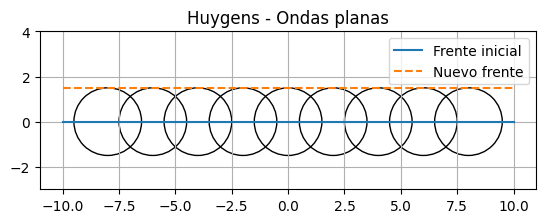

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

plt.figure()

# Frente original
plt.plot(x, np.zeros_like(x), label="Frente inicial")

# Puntos emisores
points = np.linspace(-8, 8, 9)

for p in points:
    circle = plt.Circle((p, 0), 1.5, fill=False)
    plt.gca().add_patch(circle)

# Nuevo frente (envolvente aproximada)
plt.plot(x, np.ones_like(x)*1.5, linestyle='--', label="Nuevo frente")

plt.ylim(-3, 4)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Huygens - Ondas planas")
plt.legend()
plt.grid()

plt.show()


## Ondas circulares (fuente puntual)

Para una fuente puntual, los frentes de onda son circulares:

$$
r = ct
$$

Cada punto del frente genera nuevas ondas circulares, cuya envolvente forma un círculo mayor.

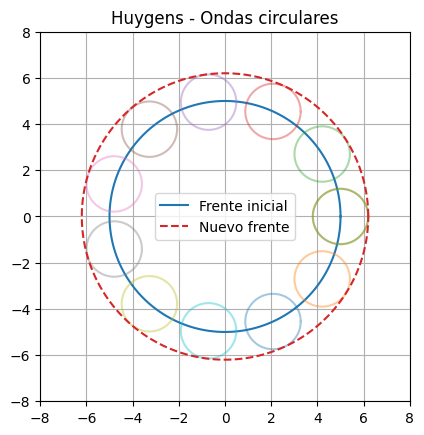

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.linspace(0, 2*np.pi, 200)

plt.figure()

# Frente principal
r = 5
x = r * np.cos(theta)
y = r * np.sin(theta)
plt.plot(x, y, label="Frente inicial")

# Ondas secundarias
angles = np.linspace(0, 2*np.pi, 12)

for t in angles:
    x0 = r * np.cos(t)
    y0 = r * np.sin(t)

    xs = x0 + 1.2 * np.cos(theta)
    ys = y0 + 1.2 * np.sin(theta)

    plt.plot(xs, ys, alpha=0.4)

# Nuevo frente (envolvente aproximada)
r2 = r + 1.2
x2 = r2 * np.cos(theta)
y2 = r2 * np.sin(theta)
plt.plot(x2, y2, linestyle='--', label="Nuevo frente")

plt.gca().set_aspect('equal')
plt.xlim(-8, 8)
plt.ylim(-8, 8)

plt.title("Huygens - Ondas circulares")
plt.legend()
plt.grid()

plt.show()


## Principio de Fermat

El principio de Fermat afirma que:

> La luz sigue el camino que minimiza el tiempo de propagación.

Esto se expresa como:

$$
\delta \int n(s)\, ds = 0
$$

donde:
- $n(s)$ es el índice de refracción
- $ds$ es un elemento del camino

En medios homogéneos, esto implica trayectorias rectilíneas.


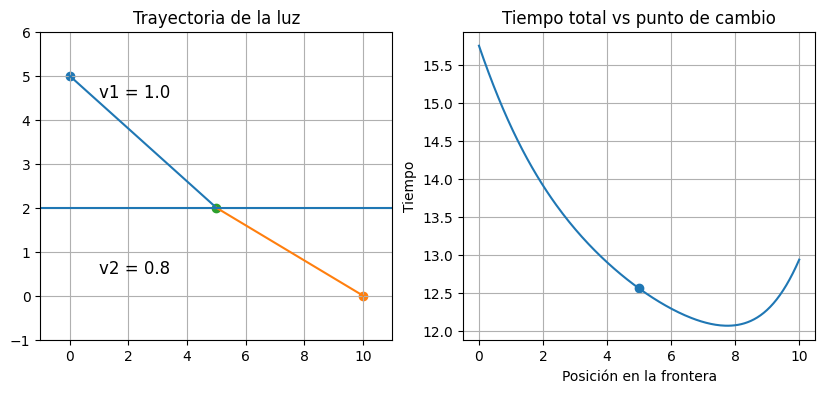

<function __main__.plot(xc)>

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

# Puntos fijos
A = np.array([0, 5])   # punto inicial (medio 1)
B = np.array([10, 0])  # punto final (medio 2)

# Velocidades
v1 = 1.0   # medio superior
v2 = 0.8   # medio inferior

# Interfaz
y_interface = 2

def tiempo_total(xc):
    C = np.array([xc, y_interface])
    d1 = np.linalg.norm(C - A)
    d2 = np.linalg.norm(B - C)
    return d1 / v1 + d2 / v2

def plot(xc):
    C = np.array([xc, y_interface])

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # --------- GRÁFICO 1: TRAYECTORIA ----------
    ax = axs[0]

    # trayectoria
    ax.plot([A[0], C[0]], [A[1], C[1]])
    ax.plot([C[0], B[0]], [C[1], B[1]])

    # puntos
    ax.scatter(*A)
    ax.scatter(*B)
    ax.scatter(*C)

    # frontera entre medios
    ax.axhline(y_interface)

    # 🔹 Etiquetas de velocidades
    ax.text(1, 4.5, f"v1 = {v1}", fontsize=12)
    ax.text(1, 0.5, f"v2 = {v2}", fontsize=12)

    ax.set_title("Trayectoria de la luz")
    ax.set_xlim(-1, 11)
    ax.set_ylim(-1, 6)
    ax.grid()

    # --------- GRÁFICO 2: TIEMPO ----------
    ax2 = axs[1]

    xs = np.linspace(0, 10, 200)
    ts = [tiempo_total(x) for x in xs]

    ax2.plot(xs, ts)

    # punto actual
    t_actual = tiempo_total(xc)
    ax2.scatter([xc], [t_actual])

    ax2.set_title("Tiempo total vs punto de cambio")
    ax2.set_xlabel("Posición en la frontera")
    ax2.set_ylabel("Tiempo")
    ax2.grid()

    plt.show()

interact(plot, xc=(0, 10, 0.1))


## Refracción y ley de Snell

A partir del principio de Fermat se puede derivar la ley de Snell:

$$
n_1 \sin \theta_1 = n_2 \sin \theta_2
$$

Esto describe cómo cambia la dirección de la luz al pasar entre medios.
